In [1]:
import numpy as np
import torch
from utils import *
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_printoptions(linewidth=100, precision=4, sci_mode=False, threshold=20000)
np.set_printoptions(linewidth=100, precision=4, suppress=True)

seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True

# env = UnityInterface("Builds\\Windows\\Ball3D\\UnityEnvironment", seed=seed)      # 1D obs only, continuous action of size 2. Rewards: 0.1 for every step, -1 for fail, 100 is the max episodic return
# env = UnityInterface("Builds\\Windows\\Crawler\\UnityEnvironment", seed=seed)     # 1D obs only, continuous action of size 8
env = UnityInterface("Builds\\Windows\\PushBlock\\UnityEnvironment", seed=seed)   # 1D obs only, discrete action of size (7). Rewards: 5 for win, -0.001 for every step
# env = UnityInterface("Builds\\Windows\\WallJump\\UnityEnvironment", seed=seed)    # 1D obs only, discrete action of size (3, 3, 3, 2)

# env = UnityInterface("Builds/Linux/Ball3D/Ball3D", seed=seed)                     # 1D obs only, continuous action of size 2. Rewards: 0.1 for every step, -1 for fail, 100 is the max episodic return
# env = UnityInterface("Builds/Linux/PushBlock/PushBlock", seed=seed)               # 1D obs only, discrete action of size (7). Rewards: 5 for win, -0.001 for every step
# env = UnityInterface("Builds/Linux/WallJump/WallJump", seed=seed)                 # 1D obs only, discrete action of size (3, 3, 3, 2)

# env = UnityInterface(None, seed=seed)                                             # Unity Editor

print(f"{env.getSpecs()}")
behaviorNames = env.getBehaviorNames()
targetEntropy, logAlpha, alpha, alphaOptimizer = {}, {}, {}, {}

agents, QNet, memory, rewards, observationBuffer, actionsBuffer, = {}, {}, {}, {}, {}, {}
totalAgentsCounts = 0
for behavior in behaviorNames:
    totalAgentsCounts += (env.getSpecs(behavior)["AgentsCount"])
    
    
# NOTE: rewards, observations and action buffers are common for all behaviors
rewards = np.zeros(totalAgentsCounts)
observationBuffer = [None] * totalAgentsCounts
for i in range(totalAgentsCounts):
    actionsBuffer[i] = {'continuous': None, 'discrete': None}

for behavior in behaviorNames:
    agents[behavior] = SAC(env.getSpecs(behavior)).to(device)
    QNet[behavior] = SoftQNetwork(env.getSpecs(behavior))
    memory[behavior] = Memory(5000)
    assert agents[behavior].usingContinuousActions or agents[behavior].usingDiscreteActions, "Agent not using continuous nor discrete actions, VERY BAD"

    # alpha[behavior] = 0.2
    targetEntropy[behavior] = torch.tensor((0), dtype=torch.float, device=device)
    divider = 0
    if agents[behavior].usingDiscreteActions:
        targetEntropy[behavior] -= torch.log(1 / torch.tensor(env.getSpecs(behavior)["DiscreteActions"]).prod().to(device))
        divider += 1
    if agents[behavior].usingContinuousActions:
        targetEntropy[behavior] -= torch.tensor(env.getSpecs(behavior)["ContinuousActions"]).to(device)
        divider += 1
    targetEntropy[behavior] /= divider
    print(f"Target entropy: {targetEntropy}")

    logAlpha[behavior] = torch.zeros(1, requires_grad=True, device=device)
    alpha[behavior] = logAlpha[behavior].exp().item()
    alphaOptimizer[behavior] = optim.Adam([logAlpha[behavior]], lr=1e-3)

gamma = 0.99
batchSize = 32
finalRewards, qnetsLosses, actorLosses, alphaLosses, alphas, QEvaluations, logProbs = [], [], [], [], [], [], []
totalSteps = 8000
for i in range(1, totalSteps+1):
    for behavior in behaviorNames:
        decisionSteps, terminalSteps = env.getSteps(behavior)
        observationsThatNeedAction = []
        for agent in decisionSteps:

            observation = decisionSteps[agent].obs
            observationsThatNeedAction.append(observation)
            reward = decisionSteps[agent].reward
            lastObservation = observationBuffer[agent]
            lastActionContinuous = actionsBuffer[agent]['continuous']
            lastActionDiscrete = actionsBuffer[agent]['discrete']
            if lastObservation != None and (lastActionContinuous != None or lastActionDiscrete != None):
                memory[behavior].push(lastObservation, lastActionContinuous, lastActionDiscrete, reward, False, observation)
            observationBuffer[agent] = observation
            rewards[agent] += reward
            
        for agent in terminalSteps:
            observation = terminalSteps[agent].obs
            reward = terminalSteps[agent].reward
            lastObservation = observationBuffer[agent]
            lastActionContinuous = actionsBuffer[agent]['continuous']
            lastActionDiscrete = actionsBuffer[agent]['discrete']
            # Technically could skip the action None check. If lastObs exist, action does too
            if lastObservation != None and (lastActionContinuous != None or lastActionDiscrete != None):
                memory[behavior].push(lastObservation, lastActionContinuous, lastActionDiscrete, reward, True, observation)
                observationBuffer[agent] = None
                actionsBuffer[agent]['continuous'] = None
                actionsBuffer[agent]['discrete'] = None
                # Save rewards only if we made an action before, otherwise the initial state was terminated state
                rewards[agent] += reward
                if rewards[agent] > 4:
                    print(f"Final reward: {rewards[agent]:>.2f}")
            finalRewards.append(rewards[agent])
            rewards[agent] = 0

        
        behaviorActionsForThisStep = {}
        specs = env.getSpecs(behavior)
        nrOfContinuousActions = specs["ContinuousActions"] # TODO: Substitute it with actors[behavior].usingContinuousActions
        nrOfDiscreteActions = len(specs["DiscreteActions"])
        behaviorActionsForThisStep["continuous"] = torch.zeros((len(decisionSteps), nrOfContinuousActions), requires_grad=False, dtype=torch.float32, device=device)
        behaviorActionsForThisStep["discrete"] = torch.zeros((len(decisionSteps), nrOfDiscreteActions), requires_grad=False, dtype=torch.int32, device=device)

        # Batched pass to get actions  
        if len(observationsThatNeedAction) > 0:
            if agents[behavior].usingContinuousActions:
                behaviorActionsForThisStep['continuous'], _ = agents[behavior].getContinuousActionAndValue(observationsThatNeedAction, withLogProbs=False)
            if agents[behavior].usingDiscreteActions:
                behaviorActionsForThisStep['discrete'], _, _ = agents[behavior].getDiscreteActionAndValue(observationsThatNeedAction, withLogProbs=False)

        # Transcribe the actions to buffer
            for j, agent in enumerate(decisionSteps):
                if nrOfContinuousActions > 0:
                    actionsBuffer[agent]['continuous'] =  behaviorActionsForThisStep['continuous'][j]
                if nrOfDiscreteActions > 0:
                    actionsBuffer[agent]['discrete'] = behaviorActionsForThisStep['discrete'][j]

        # print(f"Setting Continuous actions: {behaviorActionsForThisStep['continuous']}, Discrete actions: {behaviorActionsForThisStep['discrete']}")
        env.setActions(behavior, behaviorActionsForThisStep['continuous'].detach().cpu().numpy(), behaviorActionsForThisStep['discrete'].detach().cpu().numpy())
    env.step()

    for behavior in behaviorNames:
        if len(memory[behavior]) > batchSize*4:
            mem = memory[behavior].sample(batchSize)


            # #################### CRITIC UPDATE
            # print(f"CRITIC OPTIM")
            with torch.no_grad():
                nextStateActionsContinuous, nextStateActionsDiscrete, nextStateLogProbsContinuous, nextStateLogProbsDiscrete, nextStateProbsDiscrete, divider = None, None, 0, 0, 1, 0
                
                if agents[behavior].usingContinuousActions:
                    nextStateActionsContinuous, nextStateLogProbsContinuous = agents[behavior].getContinuousActionAndValue(mem.nextObservations)
                    divider += 1
                if agents[behavior].usingDiscreteActions:
                    nextStateActionsDiscrete, nextStateLogProbsDiscrete, nextStateProbsDiscrete = agents[behavior].getDiscreteActionAndValue(mem.nextObservations)
                    divider += 1

                QFunction1NextTarget = QNet[behavior].QNet1Target(mem.nextObservations, nextStateActionsContinuous, nextStateActionsDiscrete)
                QFunction2NextTarget = QNet[behavior].QNet2Target(mem.nextObservations, nextStateActionsContinuous, nextStateActionsDiscrete)
                # print(f"next state probs:\n{nextStateProbsDiscrete} of shape {nextStateProbsDiscrete.shape}")
                # print(f"next state log probs:\n{nextStateLogProbsDiscrete} of shape {nextStateLogProbsDiscrete.shape}")
                # print(f"min evaluation in critic optim\n{torch.min(QFunction1NextTarget, QFunction2NextTarget)} of shape {torch.min(QFunction1NextTarget, QFunction2NextTarget).shape}")
                minQNextTarget = nextStateProbsDiscrete * (torch.min(QFunction1NextTarget, QFunction2NextTarget) - alpha[behavior] * (nextStateLogProbsContinuous + nextStateLogProbsDiscrete) / divider)
                # print(f"minQNextTarget before sum:\n{minQNextTarget} of shape {minQNextTarget.shape}")

                if minQNextTarget.ndim > 1:
                    minQNextTarget = torch.sum(minQNextTarget, axis=tuple(range(1, minQNextTarget.ndim)))
                    # print(f"minQNextTarget after sum:\n{minQNextTarget} of shape {minQNextTarget.shape}")
                    # print(f"Summing minQNextTarget {minQNextTarget} of shape {minQNextTarget.shape} with sum axis {tuple(range(1, minQNextTarget.ndim))} to get {torch.sum(minQNextTarget, axis=tuple(range(1, minQNextTarget.ndim)))} of shape {torch.sum(minQNextTarget, axis=tuple(range(1, minQNextTarget.ndim))).shape}")
                
                # print(f"Resulting minQNextTarget {minQNextTarget} of shape {minQNextTarget.shape}, and it should be a shape of just (batchSize)")
                nextQValue = torch.tensor(mem.rewards, device=device, dtype=torch.float32) + torch.logical_not(torch.tensor(mem.dones, device=device)) * gamma * minQNextTarget
                # print(f"nextQValue:\n{nextQValue} of shape {nextQValue.shape}")
                
            QFunction1ActionValues = QNet[behavior].QNet1(mem.observations, torch.stack(mem.actionsContinuous).to(device).detach() if agents[behavior].usingContinuousActions else None, torch.stack(mem.actionsDiscrete).detach() if agents[behavior].usingDiscreteActions else None)
            QFunction2ActionValues = QNet[behavior].QNet2(mem.observations, torch.stack(mem.actionsContinuous).to(device).detach() if agents[behavior].usingContinuousActions else None, torch.stack(mem.actionsDiscrete).detach() if agents[behavior].usingDiscreteActions else None)
            # print(f"raw output of QNet1 before gathering\n{QFunction1ActionValues} of shape {QFunction1ActionValues.shape}")

            if agents[behavior].usingDiscreteActions:
                QFunction1ActionValues = gatherEvaluationOfTakenActions(QFunction1ActionValues, torch.stack(mem.actionsDiscrete).to(device))
                QFunction2ActionValues = gatherEvaluationOfTakenActions(QFunction2ActionValues, torch.stack(mem.actionsDiscrete).to(device))
                # print(f"output of QNet1 after gathering\n{QFunction1ActionValues} of shape {QFunction1ActionValues.shape}")
                # print(f"indexed with {torch.stack(mem.actionsDiscrete).to(device)} of shape {torch.stack(mem.actionsDiscrete).to(device).shape}")

            QFunction1Loss = F.mse_loss(QFunction1ActionValues, nextQValue)
            QFunction2Loss = F.mse_loss(QFunction2ActionValues, nextQValue)
            QFunctionsTotalLoss = QFunction1Loss + QFunction2Loss
            # print(f"mse_loss of QFunction1ActionValues and nextqvalue difference is the critic loss\n\n")

            QNet[behavior].QNetsOptimizer.zero_grad()
            QFunctionsTotalLoss.backward()
            QNet[behavior].QNetsOptimizer.step()


            # #################### ACTOR UPDATE
            # print(f"ACTOR UPDATE")
            stateActionsContinuous, stateActionsDiscrete, stateLogProbsContinuous, stateLogProbsDiscrete, stateProbsDiscrete, divider = None, None, torch.tensor(0, device=device), torch.tensor(0, device=device), torch.tensor(1, device=device), torch.tensor(0, device=device)
            
            if agents[behavior].usingContinuousActions:
                stateActionsContinuous, stateLogProbsContinuous = agents[behavior].getContinuousActionAndValue(mem.observations)
                divider += 1
            if agents[behavior].usingDiscreteActions:
                stateActionsDiscrete, stateLogProbsDiscrete, stateProbsDiscrete = agents[behavior].getDiscreteActionAndValue(mem.observations)
                divider += 1

            QFunction1Evaluation = QNet[behavior].QNet1(mem.observations, stateActionsContinuous, stateActionsDiscrete)
            QFunction2Evaluation = QNet[behavior].QNet2(mem.observations, stateActionsContinuous, stateActionsDiscrete)
            minQEvaluation = torch.min(QFunction1Evaluation, QFunction2Evaluation)
            # print(f"min evaluation {minQEvaluation} of shape {minQEvaluation.shape}")
            # print(f"state probs:\n{nextStateProbsDiscrete} of shape {nextStateProbsDiscrete.shape}")
            # print(f"state logprobs:\n{stateLogProbsDiscrete} of shape {stateLogProbsDiscrete.shape}")
            # print(f"min evaluation in actor optim:\n{minQEvaluation} of shape {minQEvaluation.shape}")
            actorLoss = (stateProbsDiscrete * ((alpha[behavior] * (stateLogProbsContinuous + stateLogProbsDiscrete) / divider) - minQEvaluation)).mean()
            # print(f"IN ACTOR OPTIM stateProbsDiscrete: {stateProbsDiscrete.shape}, logprobs: {((stateLogProbsContinuous + stateLogProbsDiscrete) / divider).shape}, minQEvaluation: {minQEvaluation.shape}")
            # print(f"actorLoss: {actorLoss}")
            # print(f"Actor loss is probs*(alpha*logprobs - minqeval).mean()\n\n")
            agents[behavior].actorOptimizer.zero_grad()
            actorLoss.backward()
            agents[behavior].actorOptimizer.step()
            
    
            # #################### ALPHA UPDATE
            # print(f"ALPHA UPDATE")
            logProbabilitiesC, logProbabilitiesD, probsD, divider = torch.tensor(0, device=device), torch.tensor(0, device=device), torch.tensor(1, device=device), 0
            if agents[behavior].usingContinuousActions:
                _, logProbabilitiesC = agents[behavior].getContinuousActionAndValue(mem.observations)
                divider += 1
            if agents[behavior].usingDiscreteActions:
                _, logProbabilitiesD, probsD = agents[behavior].getDiscreteActionAndValue(mem.observations)
                divider += 1
            alphaLoss = (probsD.detach()*(-logAlpha[behavior].exp()*((logProbabilitiesC.to(device) + logProbabilitiesD.to(device)) / divider + targetEntropy[behavior]).detach())).mean()
            # print(f"probsD:\n{probsD} of shape {probsD.shape}")
            # print(f"logprobsD:\n{logProbabilitiesD} of shape {logProbabilitiesD.shape}")
            # print(f"alpha:\n{logAlpha[behavior].exp()} of shape {logAlpha[behavior].exp().shape}")
            # print(f"target entropy:\n{targetEntropy[behavior]} of shape {targetEntropy[behavior].shape}")
            # print(f"alpha loss is: (probsD(-alpha*logprobs + target)).mean()\n\n")
            alphaOptimizer[behavior].zero_grad()
            alphaLoss.backward()
            alphaOptimizer[behavior].step()
            alpha[behavior] = logAlpha[behavior].exp().item()



            # QNETS SOFT UPDATE
            for param, targetParam in zip(QNet[behavior].QNet1.parameters(), QNet[behavior].QNet1Target.parameters()):
                targetParam.data.copy_(QNet[behavior].tau*param.data + (1 - QNet[behavior].tau)*targetParam.data)
            for param, targetParam in zip(QNet[behavior].QNet2.parameters(), QNet[behavior].QNet2Target.parameters()):
                targetParam.data.copy_(QNet[behavior].tau*param.data + (1 - QNet[behavior].tau)*targetParam.data)



            if i % 200 == 0:
                print(f"Step {i}, Actor loss: {actorLoss:>8.4f}, QF loss: {QFunctionsTotalLoss:>8.4f}")

            qnetsLosses.append(QFunctionsTotalLoss)
            actorLosses.append(actorLoss)
            alphaLosses.append(alphaLoss)
            alphas.append(alpha[behavior])
            QEvaluations.append(minQEvaluation.view(-1).mean())
            logProbs.append(((stateLogProbsContinuous + stateLogProbsDiscrete) / divider).detach().mean())
env.close()

{'PushBlock?team=0': {'AgentsCount': 32, 'Observations': [(105,), (105,)], 'ContinuousActions': 0, 'DiscreteActions': (7,)}}
Target entropy: {'PushBlock?team=0': tensor(1.9459, device='cuda:0')}
Step 200, Actor loss:  -0.6717, QF loss:   0.0026
Step 400, Actor loss:  -0.8589, QF loss:   0.0121
Step 600, Actor loss:  -1.0826, QF loss:   0.0309
Final reward: 4.38
Final reward: 4.28
Step 800, Actor loss:  -1.3386, QF loss:   0.0085
Step 1000, Actor loss:  -1.5937, QF loss:   0.0993
Step 1200, Actor loss:  -1.9018, QF loss:   0.0307
Step 1400, Actor loss:  -2.2219, QF loss:   0.0306
Final reward: 4.56
Final reward: 4.40
Step 1600, Actor loss:  -2.5770, QF loss:   0.0299
Step 1800, Actor loss:  -2.9671, QF loss:   0.0522
Final reward: 4.07
Step 2000, Actor loss:  -3.3978, QF loss:   0.1648
Step 2200, Actor loss:  -3.9988, QF loss:   0.0930
Step 2400, Actor loss:  -4.5038, QF loss:   0.0158
Final reward: 4.08
Step 2600, Actor loss:  -5.0686, QF loss:   0.1193
Step 2800, Actor loss:  -5.8161,

In [14]:
# Inspecting parameters
torch.set_printoptions(linewidth=100, precision=4, sci_mode=False, threshold=10000)

for behavior in behaviorNames:
    for name, params in agents[behavior].named_parameters():
        print(f"ENDING agent parameters {name}: {params}")

ENDING agent parameters preActor1D.0.weight: Parameter containing:
tensor([[     0.1561,      0.0819,     -0.0768,      0.1337,     -0.3035,      0.1973,     -0.0659,
              0.1864],
        [     0.1519,     -0.1896,      0.1121,      0.0227,      0.1170,     -0.0852,     -0.0321,
             -0.0608],
        [     0.4365,      0.1499,      0.2998,      0.0742,     -0.1229,     -0.2090,     -0.0380,
             -0.1461],
        [    -0.4256,     -0.1674,      0.1947,      0.1779,     -0.3293,      0.2140,      0.0926,
              0.3155],
        [     0.2220,     -0.3035,     -0.3191,     -0.1670,      0.2986,     -0.0469,      0.1705,
             -0.1625],
        [     0.5133,      0.0924,      0.2491,     -0.0013,     -0.1751,      0.1689,     -0.1645,
              0.1104],
        [    -0.2078,     -0.1207,     -0.3533,     -0.1162,      0.2103,     -0.1227,      0.3267,
              0.2939],
        [    -0.3505,     -0.2590,      0.2190,      0.1169,     -0.2222

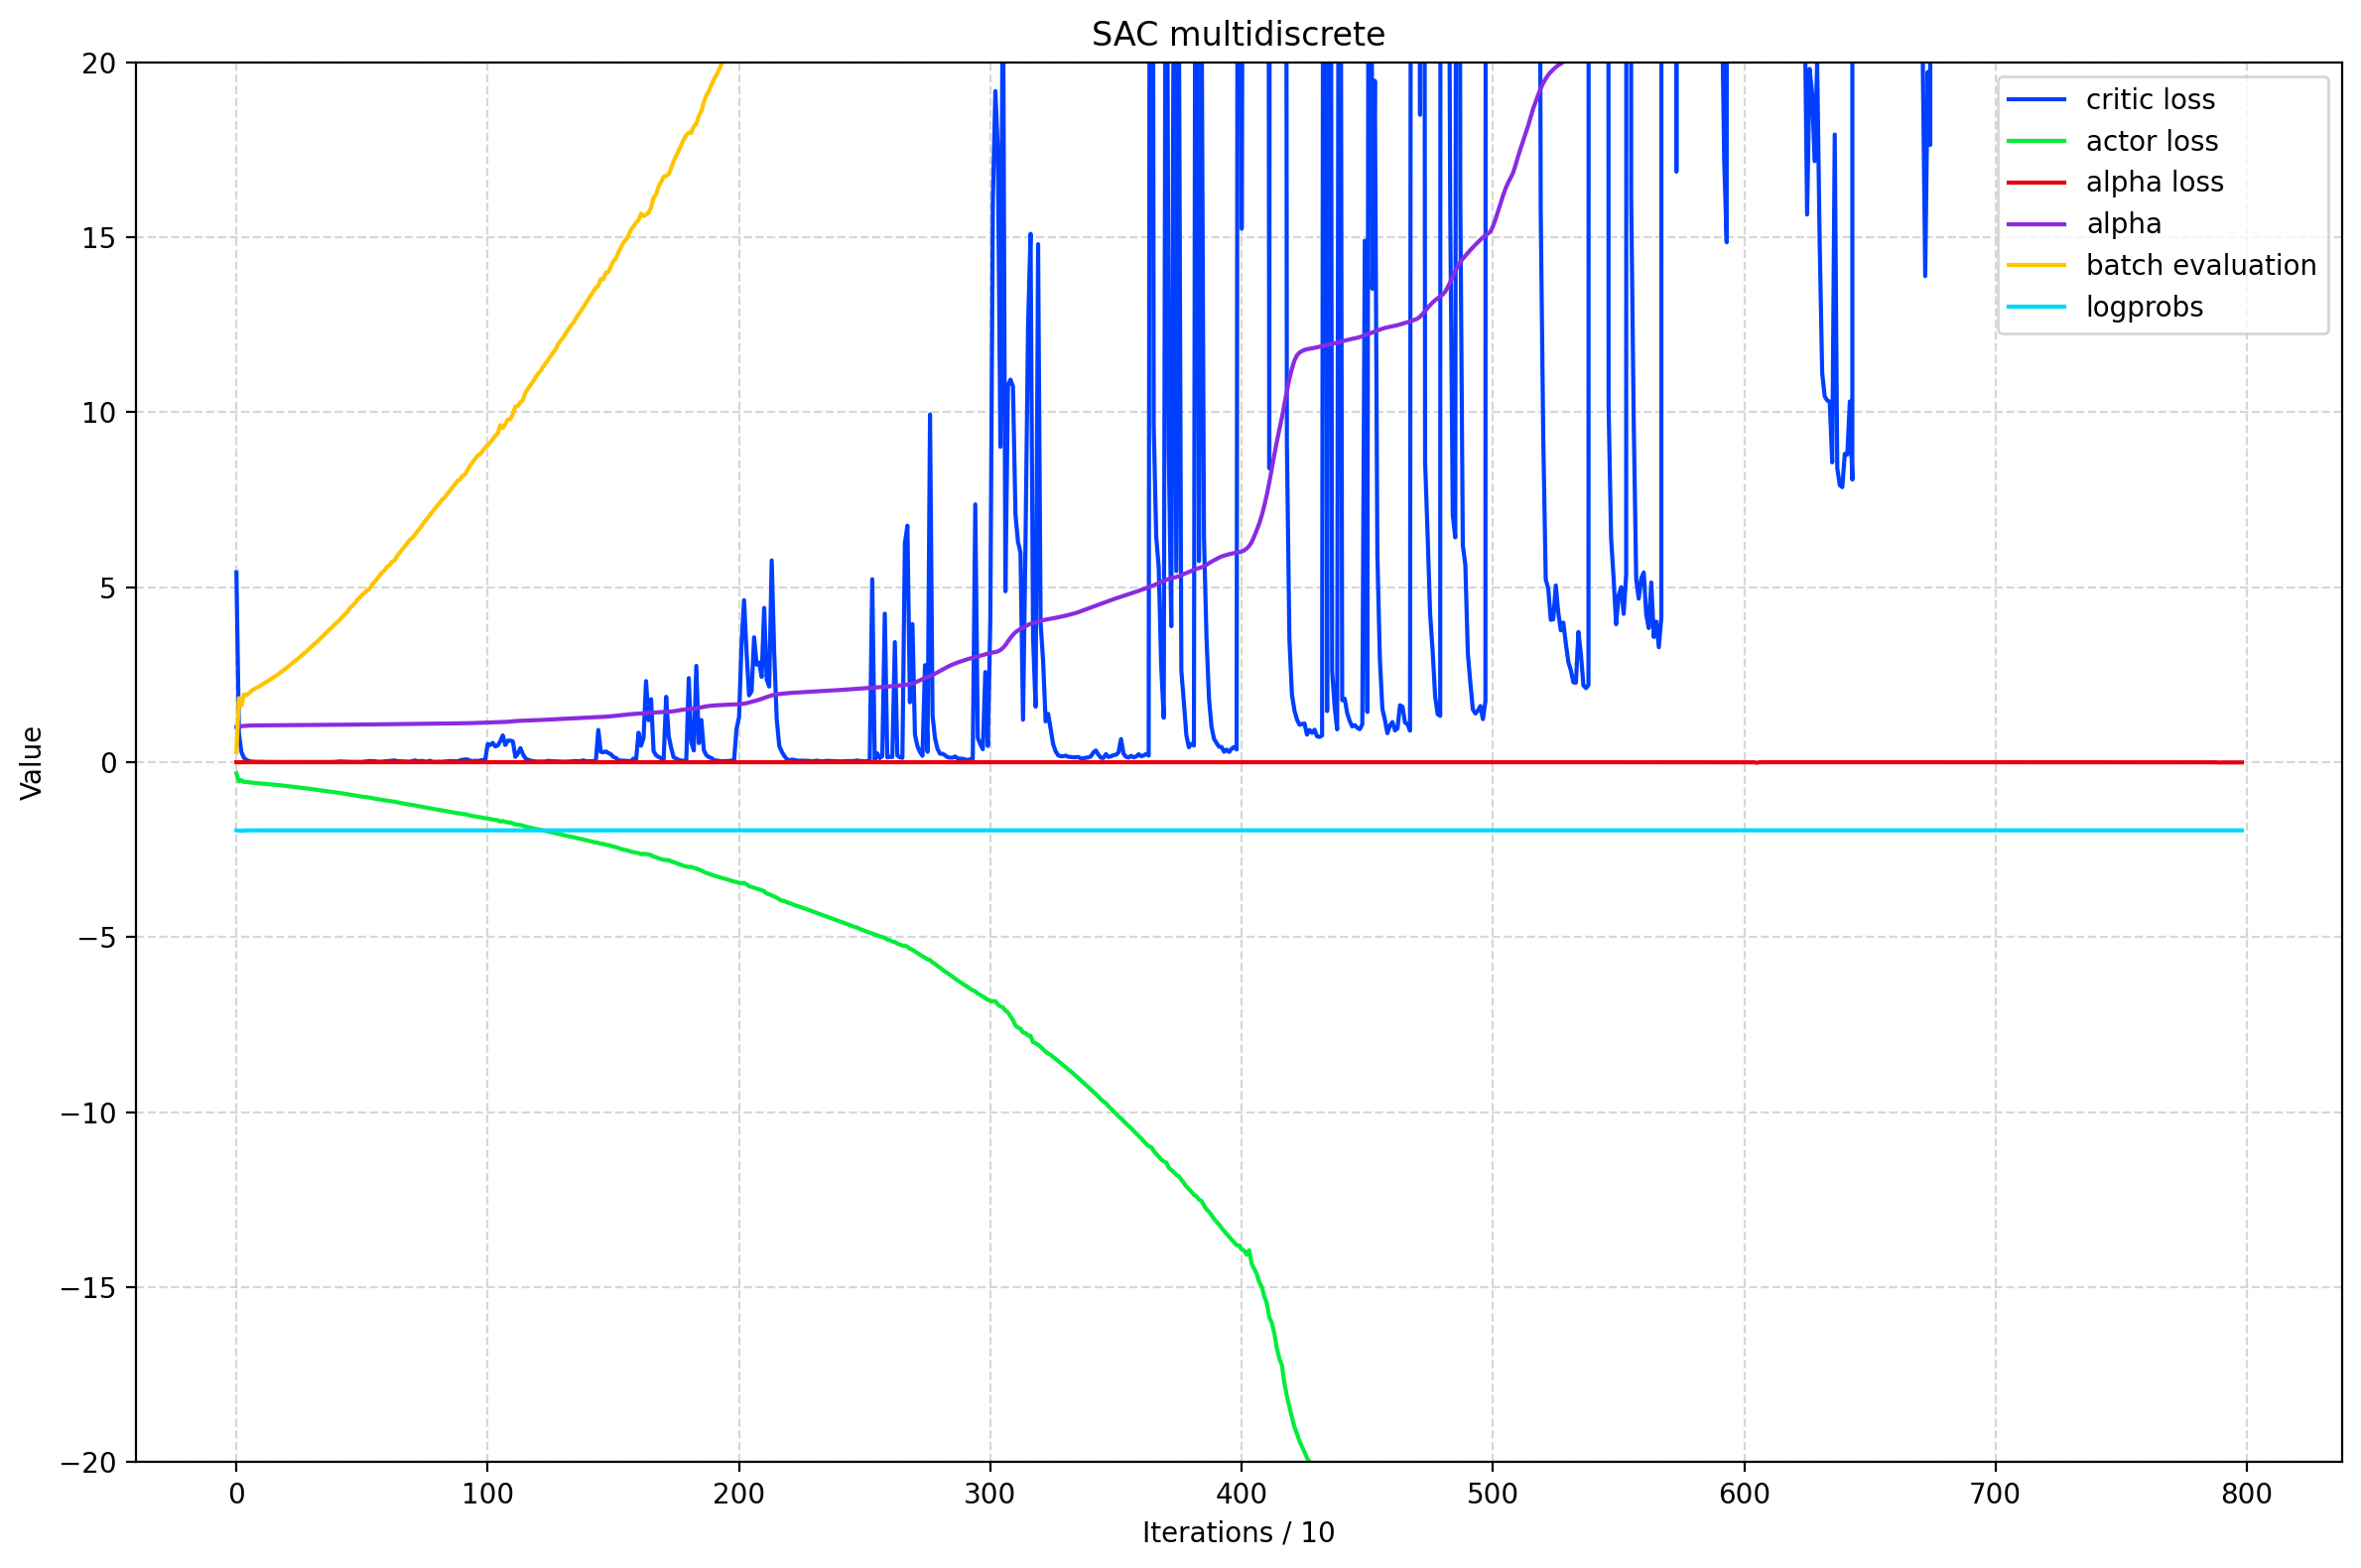

In [3]:
# Plot debug values
averagingNr = 10
beginning = 0
dif = (len(qnetsLosses) - beginning) % averagingNr

plt.style.use('seaborn-v0_8-bright')

# Creating a high-resolution figure
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

ax.plot(torch.tensor(qnetsLosses[beginning:-dif]).view(-1, averagingNr).mean(-1),       label="critic loss")
ax.plot(torch.tensor(actorLosses[beginning:-dif]).view(-1, averagingNr).mean(-1),       label="actor loss")
ax.plot(torch.tensor(alphaLosses[beginning:-dif]).view(-1, averagingNr).mean(-1),       label="alpha loss")
ax.plot(torch.tensor(alphas[beginning:-dif]).view(-1, averagingNr).mean(-1),            label="alpha")
ax.plot(torch.tensor(QEvaluations[beginning:-dif]).view(-1, averagingNr).mean(-1),      label="batch evaluation")
ax.plot(torch.tensor(logProbs[beginning:-dif]).view(-1, averagingNr).mean(-1),          label="logprobs")

ax.legend()
ax.set_title("SAC multidiscrete")
ax.set_xlabel(f"Iterations / {averagingNr}")
ax.set_ylabel("Value")

plt.ylim(-20, 20)
# plt.xlim(0, 50)

ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

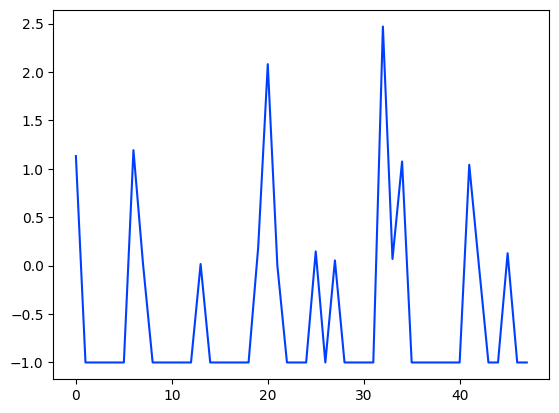

In [5]:
# Plot final rewards
averageNr = 5
dif = len(finalRewards) % averageNr
plt.plot(torch.tensor(finalRewards[:-dif]).view(-1, averageNr).mean(-1))